In [6]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch, torchvision, time, copy, random, timm
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sn
import pandas as pd
from torch.cuda.amp import autocast, GradScaler
import time
import copy
import torch
import gc


RANDOM_SEED = 2
RUN_SEEDS = {
    "baseline": 2,
    "aug_exp_01": 13,
    "aug_exp_02": 42,
}
ACTIVE_RUN_SEED = RUN_SEEDS["baseline"]


def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def seed_worker(worker_id):
    worker_seed = ACTIVE_RUN_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


seed_everything(ACTIVE_RUN_SEED)

Num_class = 5

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
import sys
print(sys.executable)
# !pwd
# %cd /content/drive/MyDrive/TCC/db-dental-radiography-classification/

e:\Rodrigo Neves\dental-radiography-classification\.venv\Scripts\python.exe


In [9]:
# Uncomment this if you are working with the zipped dataset
# with zipfile.ZipFile('/kaggle/input/dental-radiography-more-balanced-subset/Dental_Data.zip', 'r') as zip_ref:
#         # Extract all contents
#         zip_ref.extractall('./')

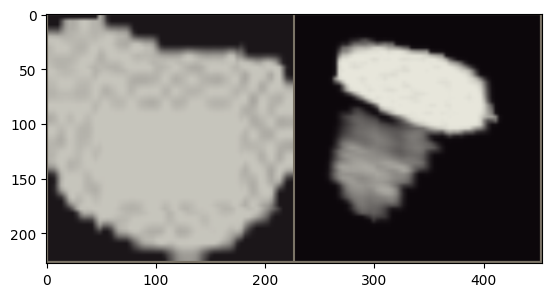

In [10]:
# Data augmentation and normalization for training
# Just normalization for validation
seed_everything(ACTIVE_RUN_SEED)

EPOCH_SEED_STRIDE = 1000003


class SeededTransformDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, seed):
        self.base_dataset = base_dataset
        self.seed = int(seed)
        self.epoch = 0
        self.classes = getattr(base_dataset, "classes", None)
        self.class_to_idx = getattr(base_dataset, "class_to_idx", None)

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        combined_seed = self.seed + (self.epoch * EPOCH_SEED_STRIDE) + index
        random.seed(combined_seed)
        np.random.seed(combined_seed % (2**32 - 1))
        torch.manual_seed(combined_seed)
        torch.cuda.manual_seed(combined_seed)
        return self.base_dataset[index]


train_transforms = transforms.Compose([
    transforms.RandomRotation(10,),
    transforms.RandomPerspective(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAutocontrast(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

eval_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.507, 0.487, 0.441], std=[0.267, 0.256, 0.276])
])

data_dir = './original-dataset'
base_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms),
    'valid': datasets.ImageFolder(os.path.join(data_dir, 'valid'), eval_transforms),
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), eval_transforms),
}

image_datasets = {
    'train': SeededTransformDataset(base_datasets['train'], ACTIVE_RUN_SEED),
    'valid': base_datasets['valid'],
    'test': base_datasets['test'],
}

loader_generator = torch.Generator()
loader_generator.manual_seed(ACTIVE_RUN_SEED)

dataloaders = {
    x: torch.utils.data.DataLoader(
        image_datasets[x],
        batch_size=2,
        shuffle=(x == 'train'),
        num_workers=0,
        generator=loader_generator if x == 'train' else None,
        worker_init_fn=seed_worker,
    )
    for x in ['train', 'valid', 'test']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.savefig('Augmented_data_train.pdf', bbox_inches = 'tight')
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out)#, title=[class_names[x] for x in classes])

In [11]:
# vit: Vision Transformer
model_ft = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=Num_class)

model_ft.set_grad_checkpointing(True)

#model_ft = models.wide_resnet101_2(pretrained=True)
#num_ftrs = model_ft.fc.in_features
#model_ft.fc = nn.Linear(num_ftrs, Num_class)

In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, accumulation_steps=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    scaler = GradScaler()
    torch.backends.cudnn.benchmark = False 

    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': []
    }

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
                loader_generator.manual_seed(ACTIVE_RUN_SEED + epoch)
            else:
                model.eval()

            if hasattr(dataloaders[phase].dataset, "set_epoch"):
                dataloaders[phase].dataset.set_epoch(epoch if phase == 'train' else 0)

            running_loss = 0.0
            running_corrects = 0
            optimizer.zero_grad()

            for i, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(enabled=(phase == 'train')):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    # Extraimos os numeros puros e somamos as estatisticas
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()

                    # Treinamento e Acumulacao
                    if phase == 'train':
                        scaled_loss = loss / accumulation_steps
                        scaler.scale(scaled_loss).backward()

                        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloaders[phase]):
                            scaler.step(optimizer)
                            scaler.update()
                            optimizer.zero_grad()
                            
                            # Limpeza
                            del outputs, loss, scaled_loss, preds
                            gc.collect()
                            torch.cuda.empty_cache()
                    else:
                        del outputs, loss, preds
                        torch.cuda.empty_cache()

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            # --- NOVO: Guardar os valores no historico desta epoca ---
            history[f'{phase}_loss'].append(epoch_loss)
            
            # Convertendo tensor para float se necessario, para evitar problemas no plot
            if torch.is_tensor(epoch_acc):
                history[f'{phase}_acc'].append(epoch_acc.item())
            else:
                history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    
    # Carrega os melhores pesos
    model.load_state_dict(best_model_wts)
    
    # Retorna o modelo treinado E o historico de metricas
    return model, history

In [13]:
def plot_history(history):
    # Cria uma figura com dois gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico 1: Loss (Perda)
    ax1.plot(history['train_loss'], label='Treino', marker='o')
    ax1.plot(history['valid_loss'], label='Validação', marker='o')
    ax1.set_title('Evolução do Cross-Entropy Loss')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.set_yticks(np.arange(0.0, 0.81, 0.1))
    ax1.set_ylim(0.0, 0.8)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Gráfico 2: Accuracy (Acurácia)
    ax2.plot(history['train_acc'], label='Treino', marker='o')
    ax2.plot(history['valid_acc'], label='Validação', marker='o')
    ax2.set_title('Evolução da Acurácia')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Acurácia')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Salva a imagem para usar no relatório/TCC
    fig.savefig('curvas_treinamento_baseline.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'")

Epoch 0/14
----------
train Loss: 0.9542 Acc: 0.6109
valid Loss: 0.6746 Acc: 0.7452

Epoch 1/14
----------
train Loss: 0.6278 Acc: 0.7569
valid Loss: 0.4837 Acc: 0.8095

Epoch 2/14
----------
train Loss: 0.5191 Acc: 0.8017
valid Loss: 0.4245 Acc: 0.8500

Epoch 3/14
----------
train Loss: 0.4713 Acc: 0.8213
valid Loss: 0.4888 Acc: 0.8119

Epoch 4/14
----------
train Loss: 0.4385 Acc: 0.8294
valid Loss: 0.4313 Acc: 0.8464

Epoch 5/14
----------
train Loss: 0.4105 Acc: 0.8388
valid Loss: 0.4600 Acc: 0.8286

Epoch 6/14
----------
train Loss: 0.3953 Acc: 0.8469
valid Loss: 0.3855 Acc: 0.8643

Epoch 7/14
----------
train Loss: 0.3059 Acc: 0.8872
valid Loss: 0.3232 Acc: 0.8821

Epoch 8/14
----------
train Loss: 0.2921 Acc: 0.8824
valid Loss: 0.3194 Acc: 0.8857

Epoch 9/14
----------
train Loss: 0.2877 Acc: 0.8891
valid Loss: 0.3257 Acc: 0.8821

Epoch 10/14
----------
train Loss: 0.2839 Acc: 0.8897
valid Loss: 0.3187 Acc: 0.8964

Epoch 11/14
----------
train Loss: 0.2771 Acc: 0.8926
valid Loss

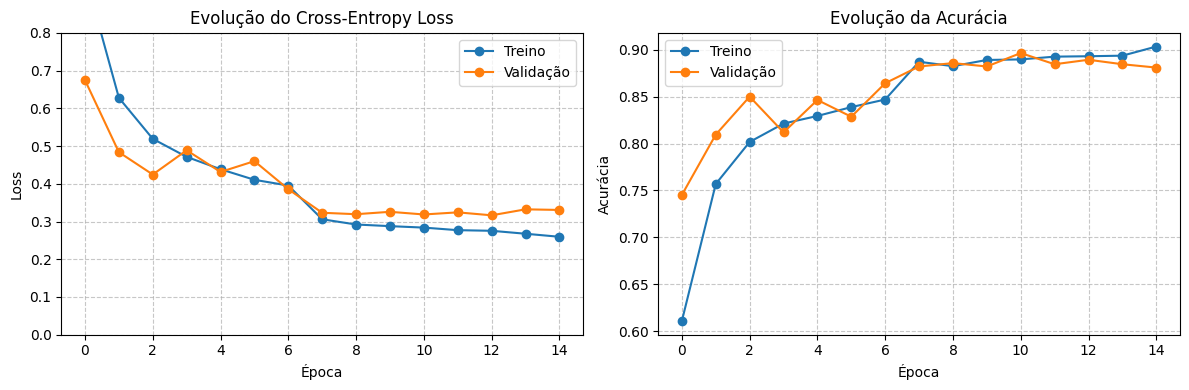

✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'


In [14]:
model_ft = model_ft.to(device)
criterion = torch.nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.0005, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Resume from checkpoint if one exists
start_epoch = 0

torch.cuda.empty_cache()
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=15)

plot_history(history)

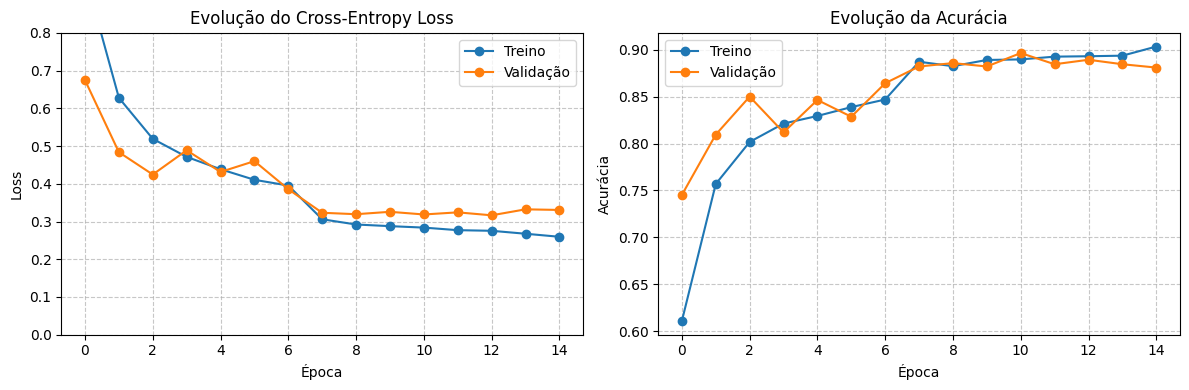

✅ Gráfico salvo com sucesso como 'curvas_treinamento_baseline.png'


In [15]:
plot_history(history)

In [16]:
def analise_de_erros_validacao(model, dataloader_valid, class_names):
    # 1. Trava o modelo em modo de avaliação (desliga Dropout, etc)
    model.eval()
    
    todas_preds = []
    todos_labels = []
    imagens_erradas = [] # Vai guardar as imagens para você analisar visualmente
    
    # 2. Desliga o cálculo de gradiente (economiza VRAM)
    with torch.no_grad():
        for inputs, labels in dataloader_valid:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            todas_preds.extend(preds.cpu().numpy())
            todos_labels.extend(labels.cpu().numpy())
            
            # 3. O pulo do gato: Capturar as imagens que ele errou!
            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    imagens_erradas.append({
                        'imagem': inputs[i].cpu(), # Tensor da imagem
                        'predito': class_names[preds[i]],
                        'real': class_names[labels[i]]
                    })

    # 4. Gera e plota a Matriz de Confusão
    cm = confusion_matrix(todos_labels, todas_preds)
    plt.figure(figsize=(10,8))
    sn.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predictions')
    plt.ylabel('Labels')
    plt.title('Confusion Matrix - Validation')
    plt.show()
    
    return imagens_erradas

def _tensor_para_imagem_numpy(img_tensor):
    img_numpy = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.507, 0.507, 0.507])
    std = np.array([0.267, 0.267, 0.267])
    img_numpy = std * img_numpy + mean
    img_numpy = np.clip(img_numpy, 0, 1)
    return img_numpy


def _monta_mosaico(imgs_numpy, grid_rows=None, grid_cols=None):
    n = len(imgs_numpy)
    if n == 0:
        return None

    if grid_rows is None and grid_cols is None:
        grid_cols = int(np.ceil(np.sqrt(n)))
        grid_rows = int(np.ceil(n / grid_cols))
    else:
        if grid_rows is None:
            grid_rows = int(np.ceil(n / grid_cols))
        if grid_cols is None:
            grid_cols = int(np.ceil(n / grid_rows))

    max_slots = grid_rows * grid_cols
    imgs_numpy = imgs_numpy[:max_slots]

    h, w, c = imgs_numpy[0].shape
    pad = np.ones((h, w, c), dtype=imgs_numpy[0].dtype)

    rows = []
    for r in range(grid_rows):
        row_imgs = []
        for c_idx in range(grid_cols):
            idx = r * grid_cols + c_idx
            if idx < len(imgs_numpy):
                row_imgs.append(imgs_numpy[idx])
            else:
                row_imgs.append(pad)
        rows.append(np.concatenate(row_imgs, axis=1))

    return np.concatenate(rows, axis=0)


def visualizar_erros(imagens_erradas, class_names, grid_rows=None, grid_cols=None, include_correct=False):
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    n_classes = len(class_names)

    cells = [[[] for _ in range(n_classes)] for _ in range(n_classes)]
    for erro in imagens_erradas:
        real = erro.get('real')
        pred = erro.get('predito')
        if real not in class_to_idx or pred not in class_to_idx:
            continue
        if (not include_correct) and real == pred:
            continue
        cells[class_to_idx[real]][class_to_idx[pred]].append(erro['imagem'])

    figsize_per_cell = 2.4
    fig, axes = plt.subplots(
        n_classes,
        n_classes,
        figsize=(figsize_per_cell * n_classes, figsize_per_cell * n_classes)
    )

    if n_classes == 1:
        axes = np.array([[axes]])

    for i, real in enumerate(class_names):
        for j, pred in enumerate(class_names):
            ax = axes[i, j]
            imgs_numpy = [_tensor_para_imagem_numpy(img) for img in cells[i][j]]
            mosaic = _monta_mosaico(imgs_numpy, grid_rows=grid_rows, grid_cols=grid_cols)

            if mosaic is not None:
                ax.imshow(mosaic)
            else:
                ax.set_facecolor('whitesmoke')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(True)

            if i == 0:
                ax.set_title(f"Pred: {pred}")
            if j == 0:
                ax.set_ylabel(f"Real: {real}")

    plt.tight_layout()
    plt.show()



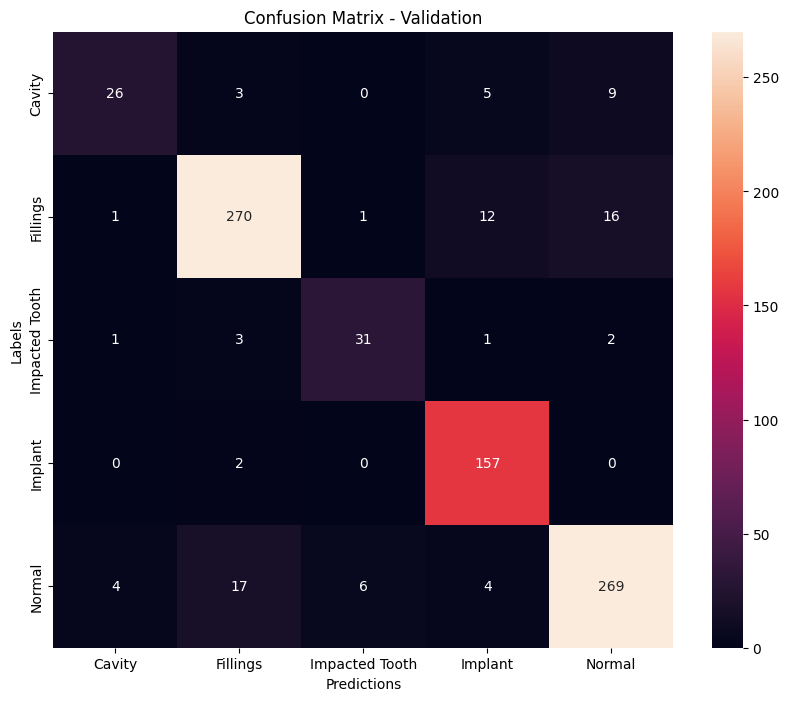

In [17]:
wrong_images = analise_de_erros_validacao(model_ft, dataloaders['valid'], class_names)
# visualizar_erros(wrong_images, class_names, 3, 5)

In [7]:
y_pred = []
y_true = []
output_all =[]

# iterate over test data
for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        output = model_ft(inputs) # Feed Network
        #output = output[:,0:2]

        output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
        y_pred.extend(output) # Save Prediction

        labels = labels.data.cpu().numpy()
        y_true.extend(labels) # Save Truth

Test Accuracy: 0.8482849604221636
Test F1 Score (macro): 0.7522303753572752
Test F1 Score (weighted): 0.851784223407376


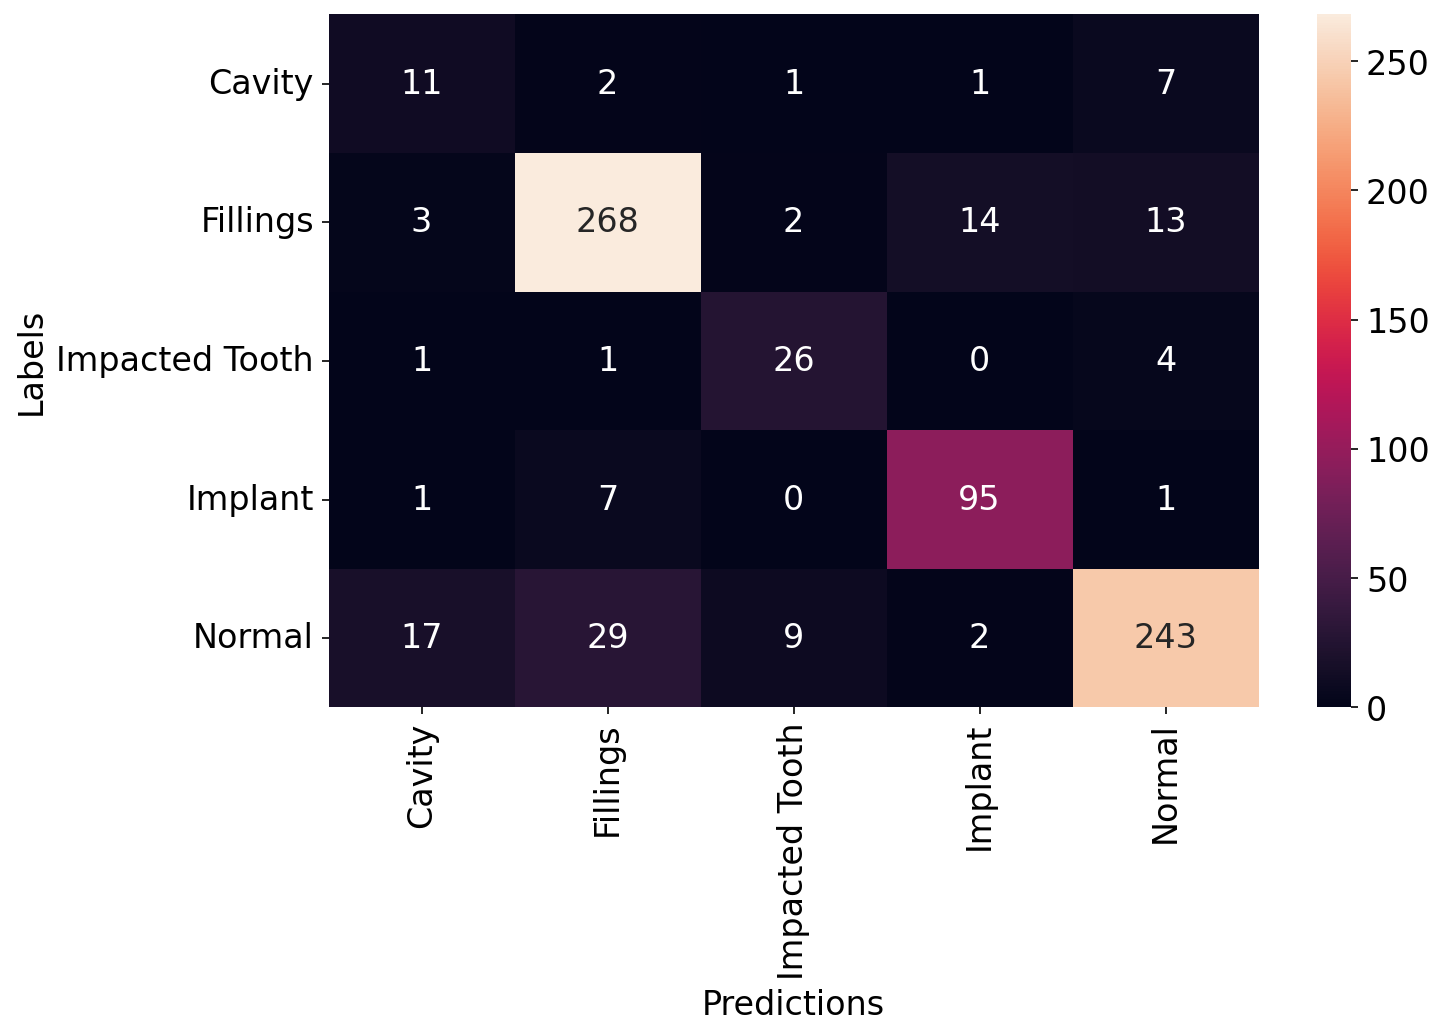

In [8]:
test_accuracy = 0
for iter1 in range(len(y_true)):
    if y_true[iter1] == y_pred[iter1]:
        test_accuracy = test_accuracy + 1

print('Test Accuracy:', test_accuracy / len(y_true))

# F1 scores computed only on test predictions
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
print('Test F1 Score (macro):', test_f1_macro)
print('Test F1 Score (weighted):', test_f1_weighted)

classes = ('Cavity','Fillings','Impacted Tooth','Implant','Normal')

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])



plt.figure(figsize = (10,6),dpi=150)
plt.rcParams['font.size'] = '16'
fig = sn.heatmap(df_cm, annot=True, fmt=".0f")
plt.ylabel("Labels")
plt.xlabel("Predictions")
plt.show(fig)

fig.figure.savefig('Confusion_test.pdf', bbox_inches = 'tight')